In [ ]:
import os
import torch
import torch.nn.functional as F
import numpy as np

from model.architecture.siamese_model import SiameseAHPModel
from data_augmentation.matrices_loader import MatricesLoader
from utils.phase import Phase
from visualization.data.weights_visualizator import WeightsVisualizator
from visualization.results.metrics_visualizator import MetricsVisualizator
from metrics.evaluator import Evaluator
from analytic_methods.EVM_method import EVM

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device used: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device used: cpu


In [3]:
IS_UNIFORM = True
CRITERIA_NUM = 5
CONSISTENCY_RATES = [0.01, 0.02, 0.03, 0.04, 0.05, 0.07, 0.08, 0.1, 0.12, 0.14, 0.15, 
                     0.17, 0.18, 0.2, 0.23, 0.27, 0.3, 0.33, 0.37, 0.4]

In [4]:
def load_test_matrices(loader: MatricesLoader):
    all_matrices = {}
    all_weights = {}

    for cr in CONSISTENCY_RATES:
        matrices, weights = loader.load_noisy_cr_matrices(Phase.TEST, cr, IS_UNIFORM)
        all_matrices[cr] = matrices
        all_weights[cr] = weights

    print(f"{len(list(all_matrices.keys()))} matrices and weights with different cr was successfully uploaded")
    return all_matrices, all_weights


def load_model_weights(model: torch.nn.Module, model_type_name: str, file_name: str, device: torch.device):
    base_dir = "models"
    dir_path = os.path.join(base_dir, model_type_name)
    file_path = os.path.join(dir_path, file_name)

    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File was not found: {file_path}")

    state_dict = torch.load(file_path, map_location=device)
    model.load_state_dict(state_dict)
    model.eval()
    
    print(f"Model: {file_name.split('.')[0]} was loaded from {dir_path}")
    return model

In [5]:
def predict_weights(model: torch.nn.Module, matrix: np.ndarray, device: torch.device) -> np.ndarray:
    model.eval()

    tensor_matrix = torch.tensor(matrix, dtype=torch.float32).to(device)
    tensor_log = torch.log(tensor_matrix + 1e-8)
    tensor_input = tensor_log.unsqueeze(0).unsqueeze(0)

    with torch.no_grad():
        logits = model.encoder(tensor_input)
        weights = F.softmax(logits, dim=1)

    final_weights = weights.squeeze(0).cpu().numpy()
    return final_weights

In [6]:
model = SiameseAHPModel(n_criteria=CRITERIA_NUM)
trained_model = load_model_weights(model, "siamese", "basic_model.pth", device)

loader = MatricesLoader()
matrices, weights = load_test_matrices(loader)
predicted_priority_weights = {}
evm_solver = EVM()
evm_priority_weights = {}

for cr, test_matrix in matrices.items():
    predicted_priority_vector = predict_weights(trained_model, test_matrix, device)
    evm_priority_vector, _ = evm_solver.compute_single(test_matrix)

    predicted_priority_weights[cr] = predicted_priority_vector
    evm_priority_weights[cr] = evm_priority_vector


print("Predicted AHP weights:")
for i, weight in enumerate(predicted_priority_vector):
    print(f"Criterium {i+1}: {weight:.4f}")

Model: basic_model was loaded from models/siamese
Successfuly uploaded 1 noised matrices (level: c001).
Successfuly uploaded 1 noised matrices (level: c002).
Successfuly uploaded 1 noised matrices (level: c003).
Successfuly uploaded 1 noised matrices (level: c004).
Successfuly uploaded 1 noised matrices (level: c005).
Successfuly uploaded 1 noised matrices (level: c007).
Successfuly uploaded 1 noised matrices (level: c008).
Successfuly uploaded 1 noised matrices (level: c010).
Successfuly uploaded 1 noised matrices (level: c012).
Successfuly uploaded 1 noised matrices (level: c014).
Successfuly uploaded 1 noised matrices (level: c015).
Successfuly uploaded 1 noised matrices (level: c017).
Successfuly uploaded 1 noised matrices (level: c018).
Successfuly uploaded 1 noised matrices (level: c020).
Successfuly uploaded 1 noised matrices (level: c023).
Successfuly uploaded 1 noised matrices (level: c027).
Successfuly uploaded 1 noised matrices (level: c030).
Successfuly uploaded 1 noised ma

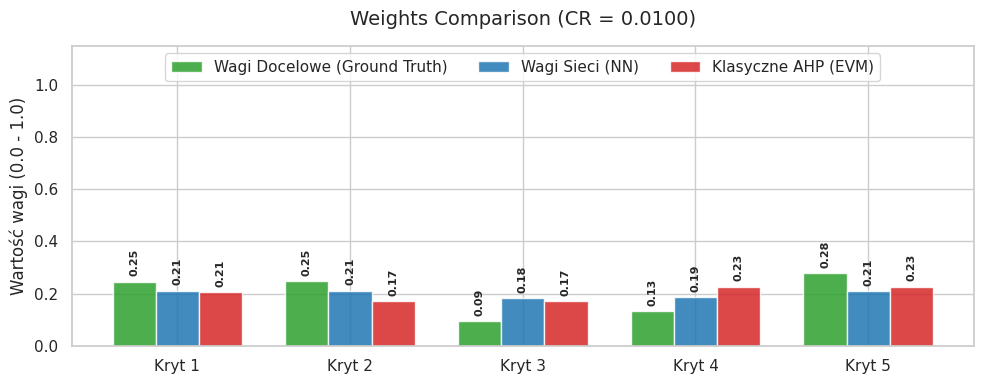

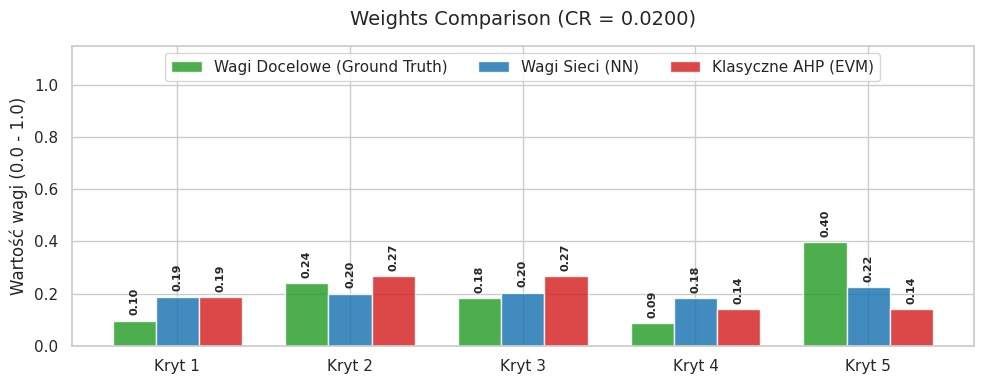

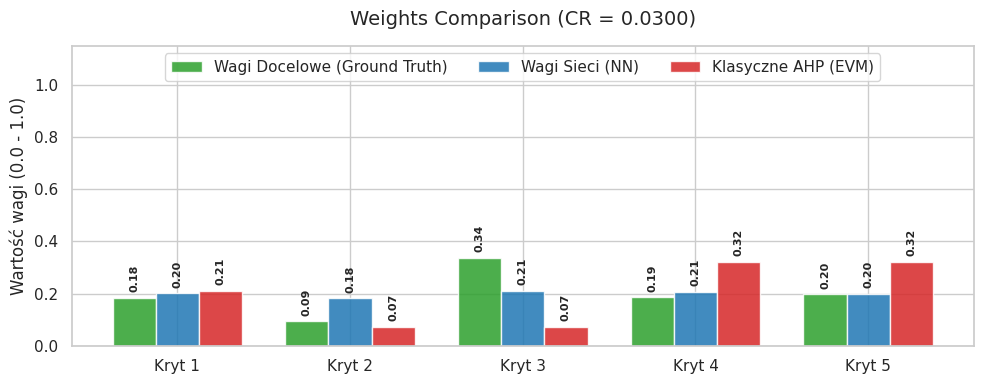

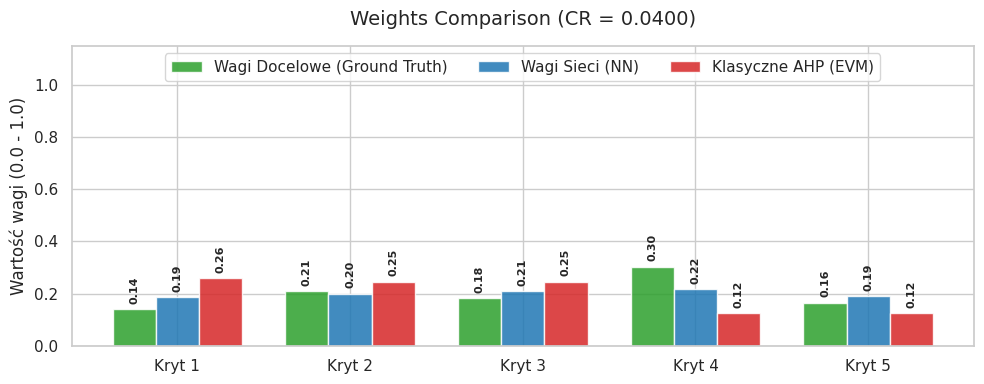

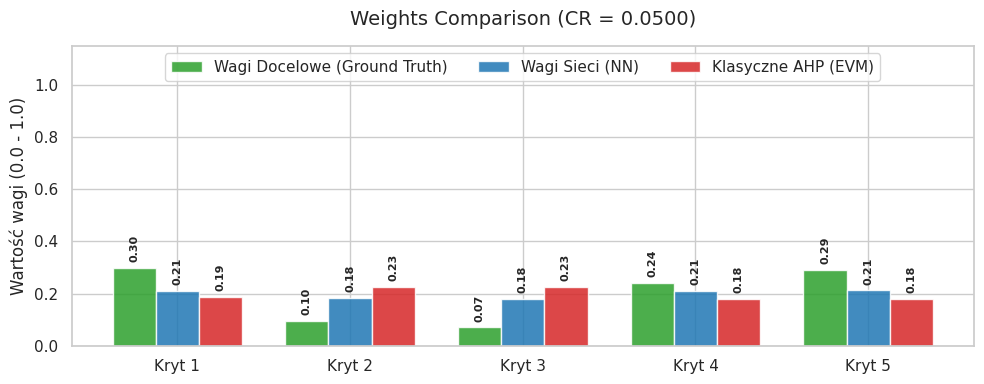

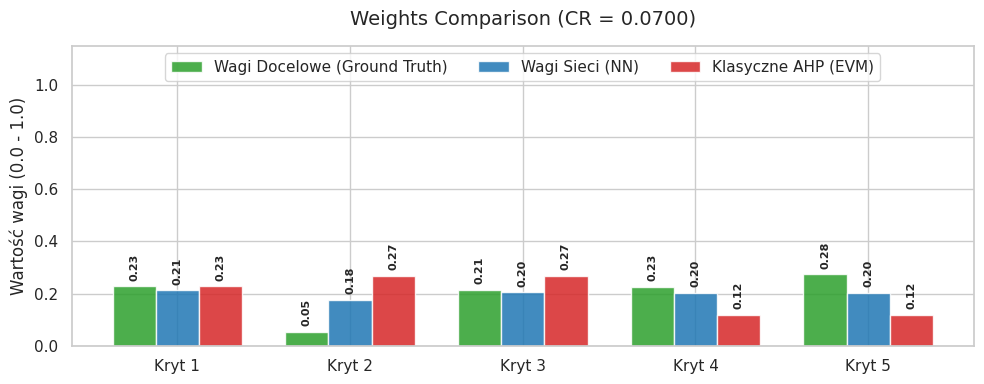

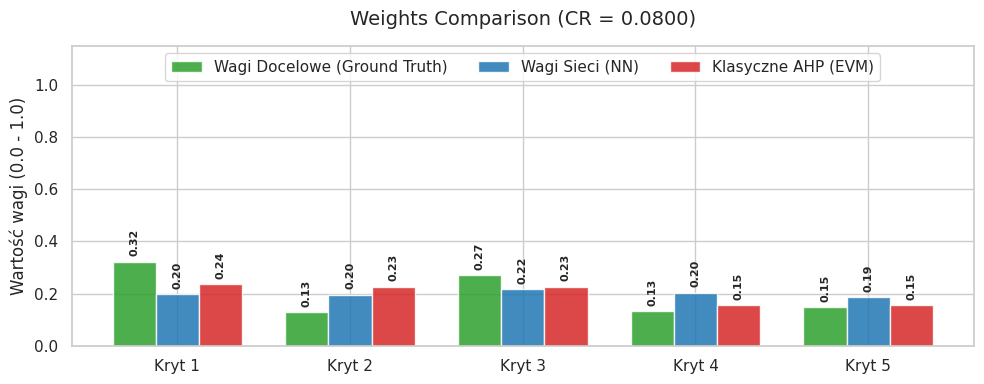

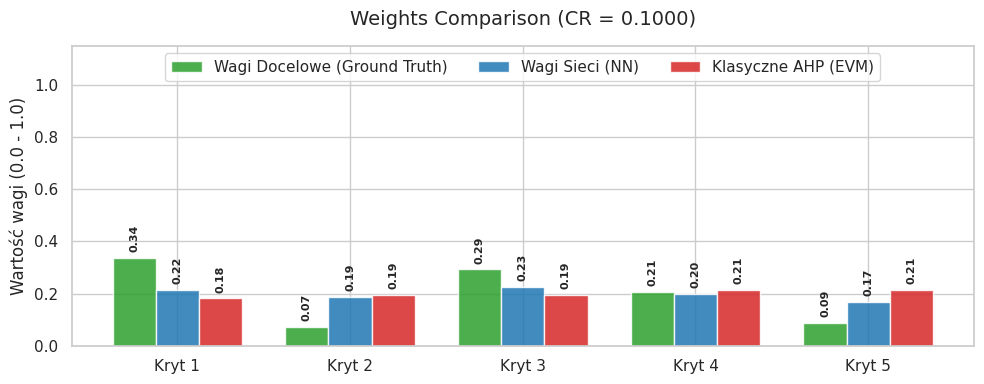

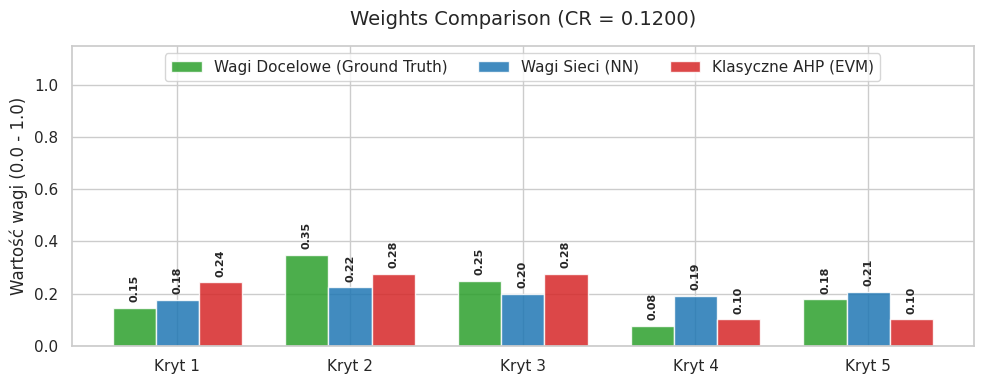

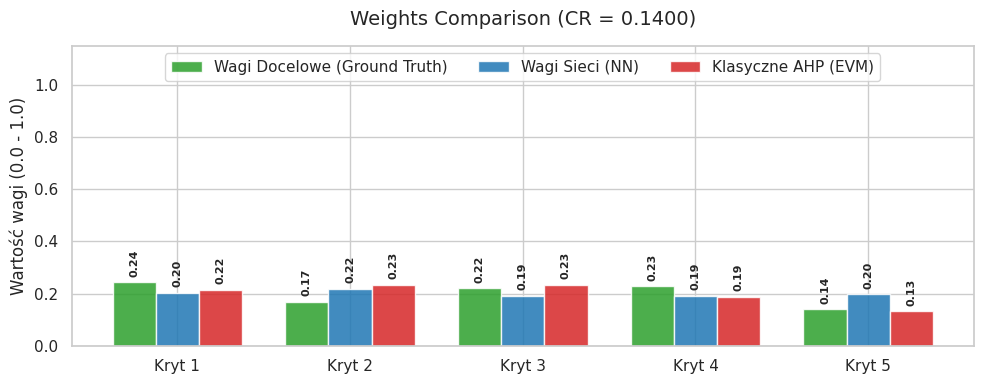

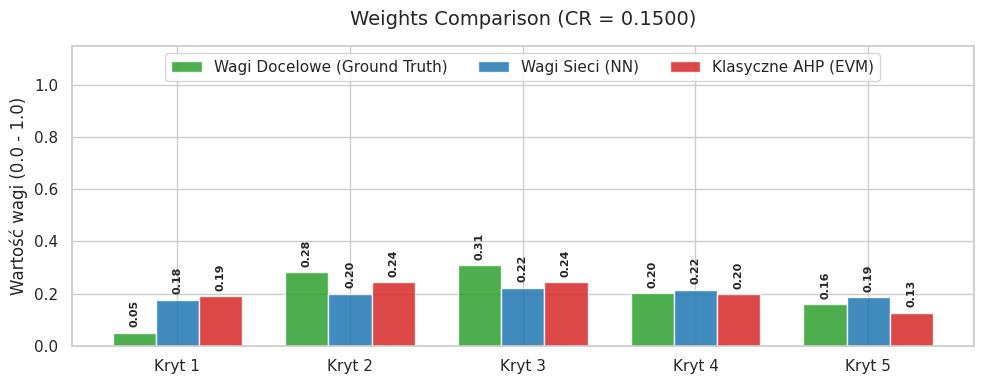

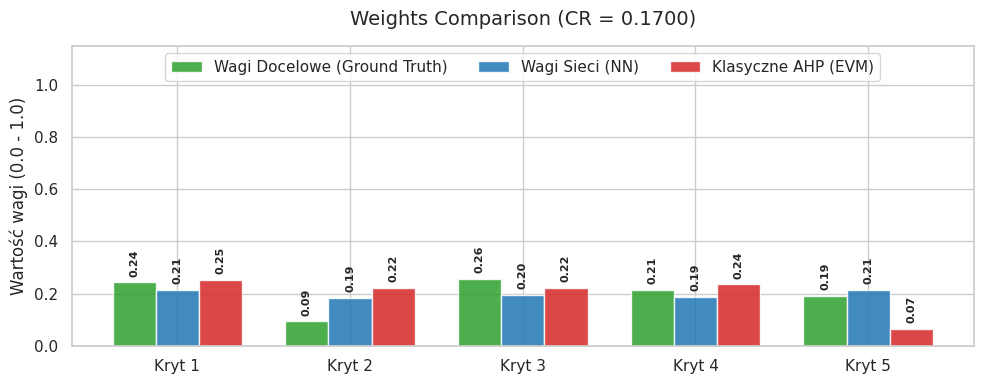

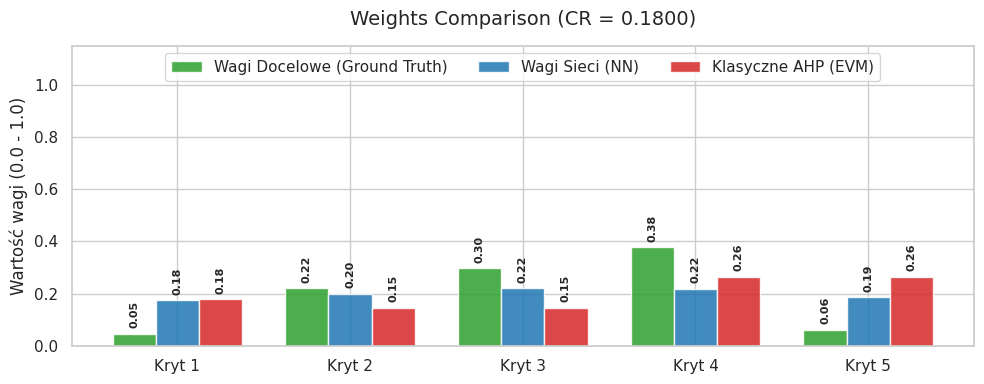

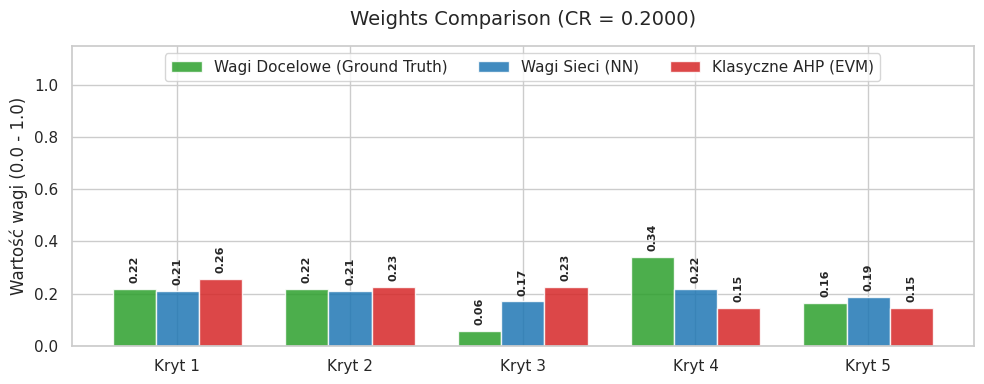

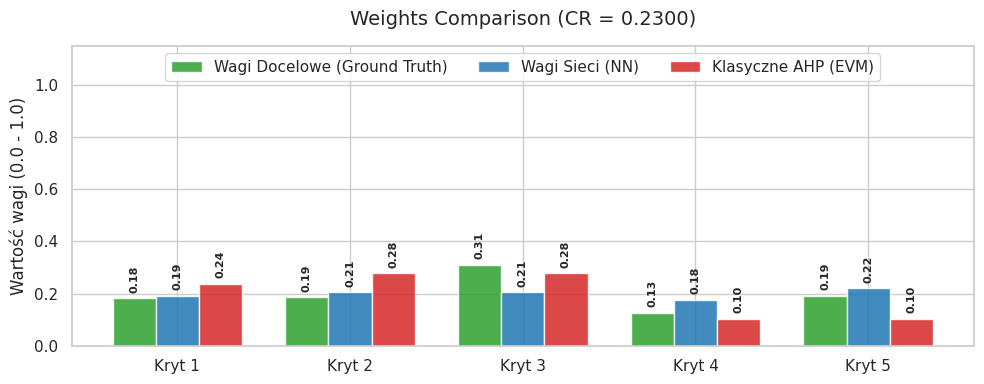

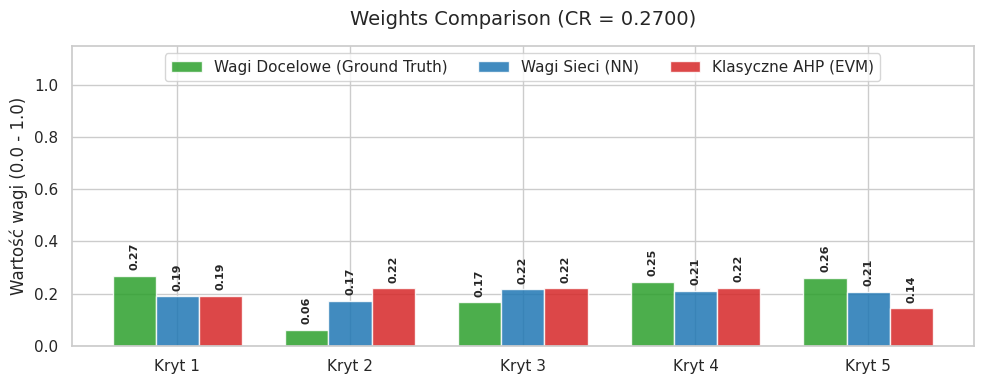

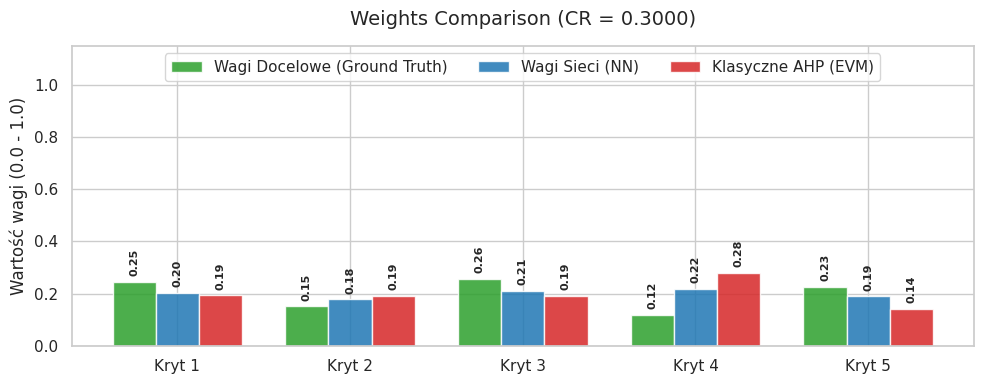

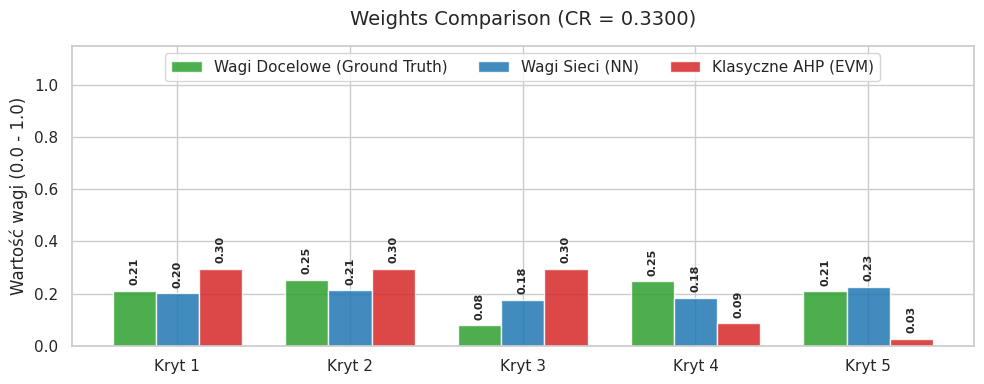

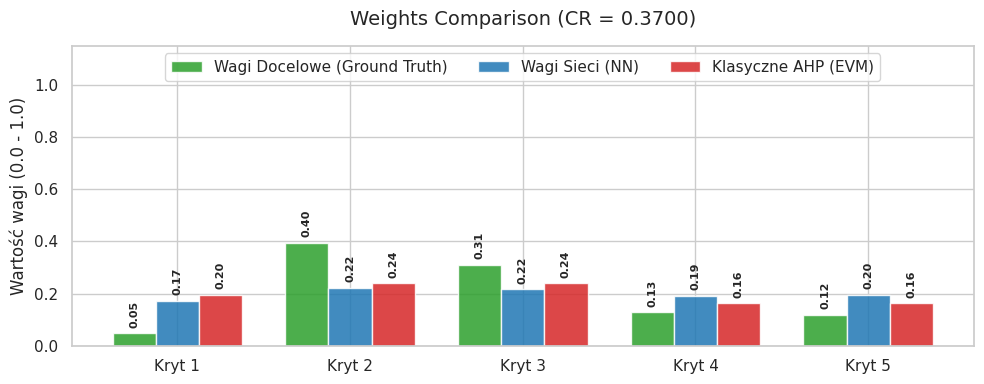

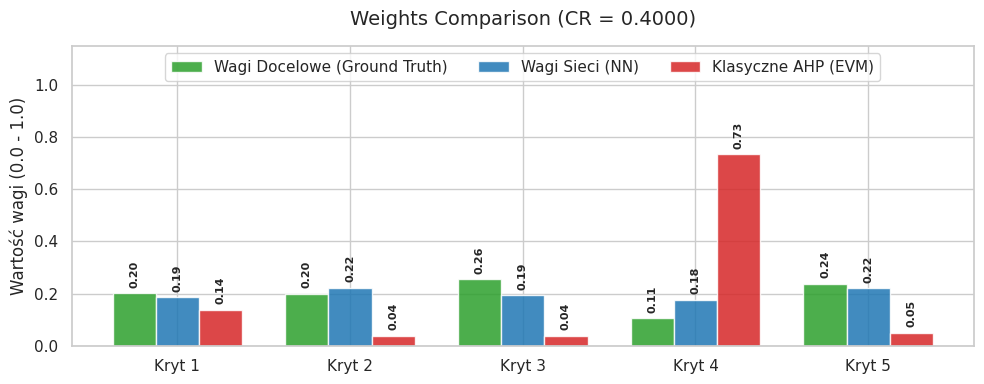

In [7]:
weights_visualizator = WeightsVisualizator()

for cr_key in weights.keys():
    pred_weights_vector = predicted_priority_weights.get(cr_key)
    evm_weights_vector = evm_priority_weights.get(cr_key).flatten()
    weights_vector = weights.get(cr_key).flatten()

    weights_visualizator.plot_comparison_all(weights_vector, pred_weights_vector, evm_weights_vector, cr_key)


--- WYNIKI GLOBALNE EKSPERYMENTU ---
Przeanalizowano łącznie 20 macierzy.
Globalny średni CR: 0.1630
Globalny średni błąd MAE (EVM): 0.0942, NN: 0.0618740350086275
Globalna średnia korelacja Kendalla (EVM): 0.0276, NN: 0.4699999999999999


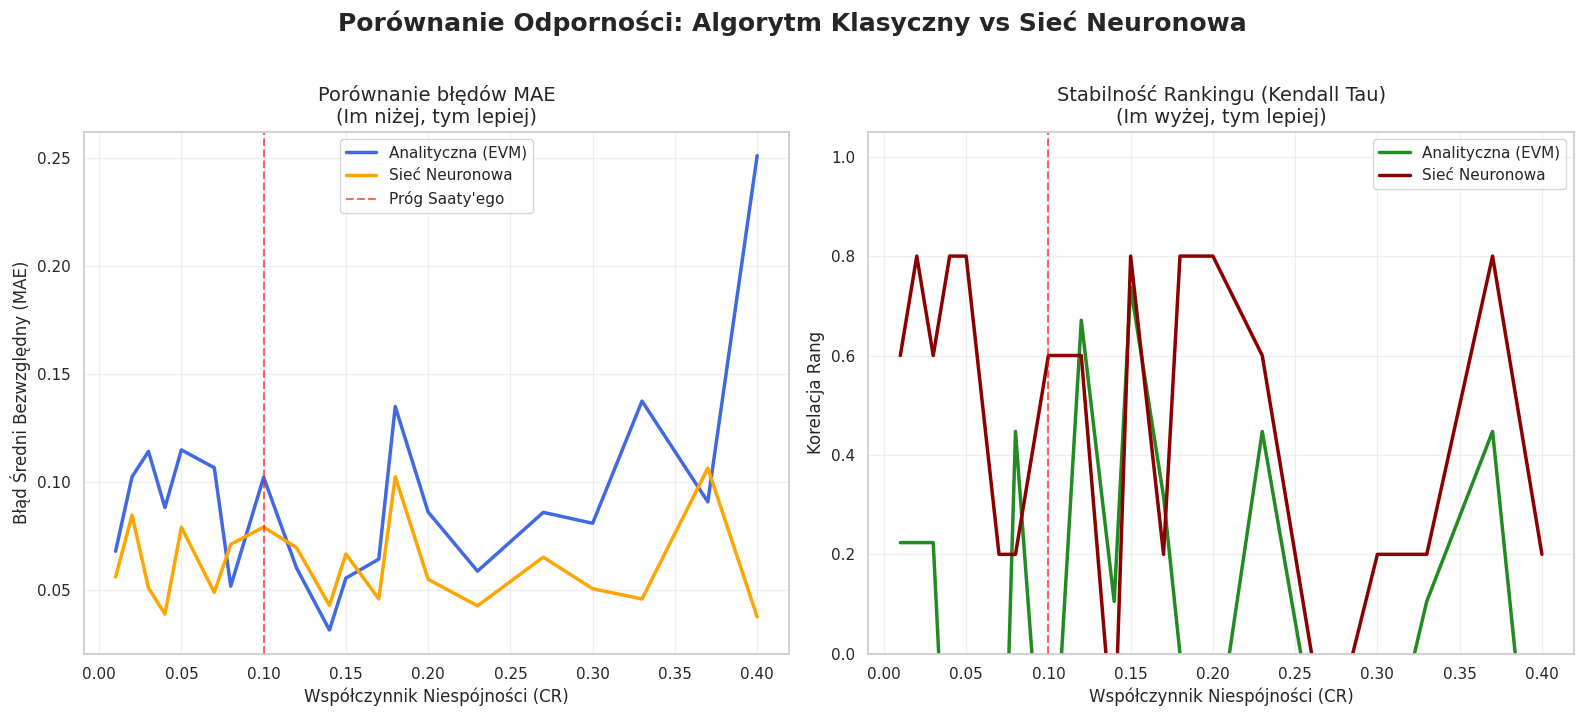

In [8]:
evm_solver = EVM()
evaluator = Evaluator()

all_mae_evm = []
all_kendall_taus_evm = []

all_mae_nn= []
all_kendall_taus_nn = []

for test_matrix, weights_vector, pred_weights_vector in zip(matrices.values(), weights.values(), predicted_priority_weights.values()):
    evm_weights_vector, cr_values = evm_solver.compute_single(test_matrix)
    mae_evm, kendall_taus_evm = evaluator.evaluate_single(weights_vector, evm_weights_vector)
    mae_nn, kendal_taus_nn = evaluator.evaluate_single(weights_vector, pred_weights_vector)

    all_mae_evm.append(mae_evm)
    all_kendall_taus_evm.append(kendall_taus_evm)
    all_mae_nn.append(mae_nn)
    all_kendall_taus_nn.append(kendal_taus_nn)

final_mae_evm = np.array(all_mae_evm)
final_kendall_taus_evm = np.array(all_kendall_taus_evm)
final_mae_nn = np.array(all_mae_nn)
final_kendal_taus_nn = np.array(all_kendall_taus_nn)

print("\n--- WYNIKI GLOBALNE EKSPERYMENTU ---")
print(f"Przeanalizowano łącznie {len(CONSISTENCY_RATES)} macierzy.")
print(f"Globalny średni CR: {np.mean(CONSISTENCY_RATES):.4f}")
print(f"Globalny średni błąd MAE (EVM): {np.mean(final_mae_evm):.4f}, NN: {np.mean(final_mae_nn)}")
print(f"Globalna średnia korelacja Kendalla (EVM): {np.mean(final_kendall_taus_evm):.4f}, NN: {np.mean(final_kendal_taus_nn)}")

viz = MetricsVisualizator()
viz.plot_comparison(CONSISTENCY_RATES, final_mae_evm, final_kendall_taus_evm, final_mae_nn, final_kendal_taus_nn)